In [23]:
# Upload the Instagram dataset to Colab
from google.colab import files
uploaded = files.upload()


Saving Instagram data.csv to Instagram data (1).csv


In [25]:
import pandas as pd

# Replace with exact filename if needed
df = pd.read_csv("/content/Instagram data (1).csv", encoding='latin-1') # Changed the encoding to 'latin-1'

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Apply the Seaborn style
sns.set_theme(style="darkgrid")  # Seaborn provides various styles, e.g., 'darkgrid', 'whitegrid', 'dark', 'white', 'ticks'

# The 'Set2' palette is already the default in Seaborn
# If you want to be explicit:
sns.set_palette('Set2')

import warnings
warnings.filterwarnings('ignore')

In [30]:
# 📌 STEP 2: Load the CSV
df = pd.read_csv("/content/Instagram data (1).csv", encoding='latin-1')

# 📌 STEP 3: Basic Info
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)
df.info()
df.head()


Dataset Shape: (119, 13)

Columns:
 Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits',
       'Follows', 'Caption', 'Hashtags'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     119 non-null    int64 
 1   From Home       119 non-null    int64 
 2   From Hashtags   119 non-null    int64 
 3   From Explore    119 non-null    int64 
 4   From Other      119 non-null    int64 
 5   Saves           119 non-null    int64 
 6   Comments        119 non-null    int64 
 7   Shares          119 non-null    int64 
 8   Likes           119 non-null    int64 
 9   Profile Visits  119 non-null    int64 
 10  Follows         119 non-null    int64 
 11  Caption         119 non-null    object
 12  Hashtags        119 non-nul

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


In [31]:
# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Drop missing rows (optional)
df.dropna(inplace=True)

# Convert date column if exists
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')



Missing Values:
 Impressions       0
From Home         0
From Hashtags     0
From Explore      0
From Other        0
Saves             0
Comments          0
Shares            0
Likes             0
Profile Visits    0
Follows           0
Caption           0
Hashtags          0
dtype: int64


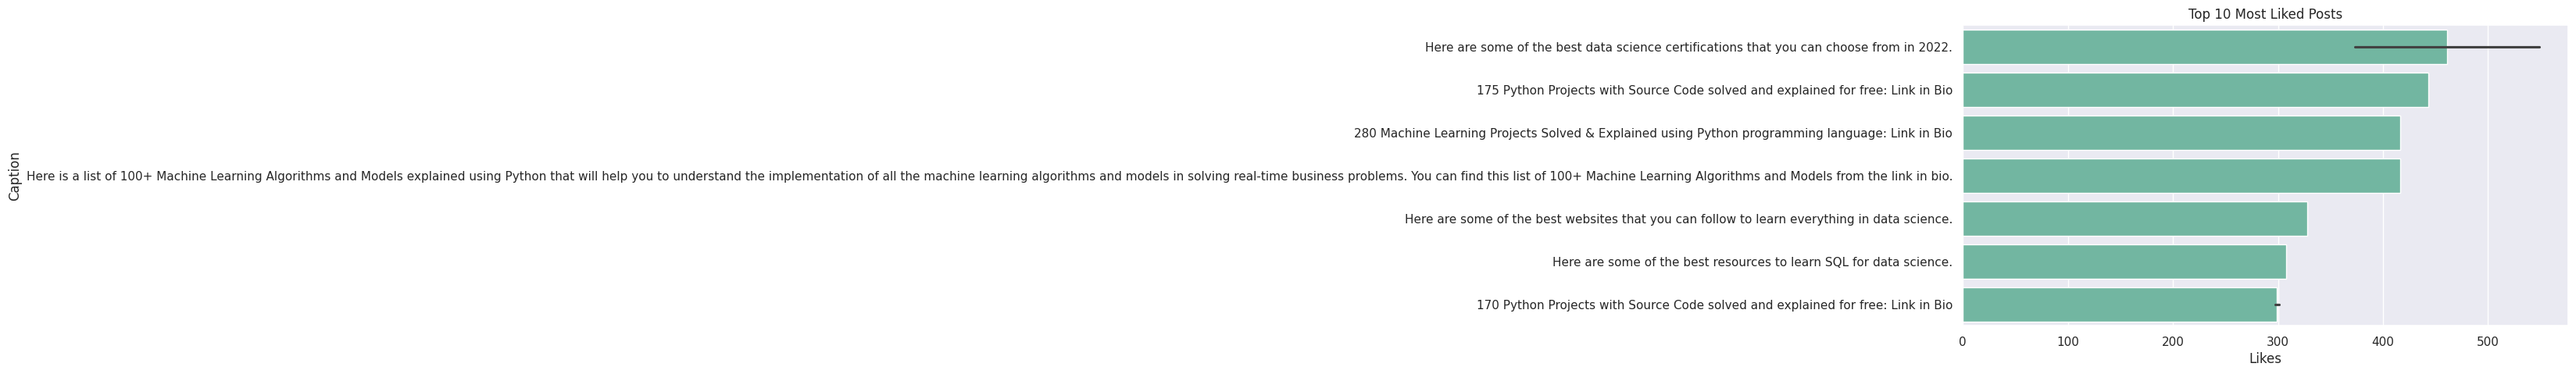

In [38]:
# Top liked posts
top_liked = df.sort_values(by='Likes', ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x='Likes', y='Caption', data=top_liked)
plt.title("Top 10 Most Liked Posts")
plt.xlabel("Likes")
plt.ylabel("Caption")
plt.show()

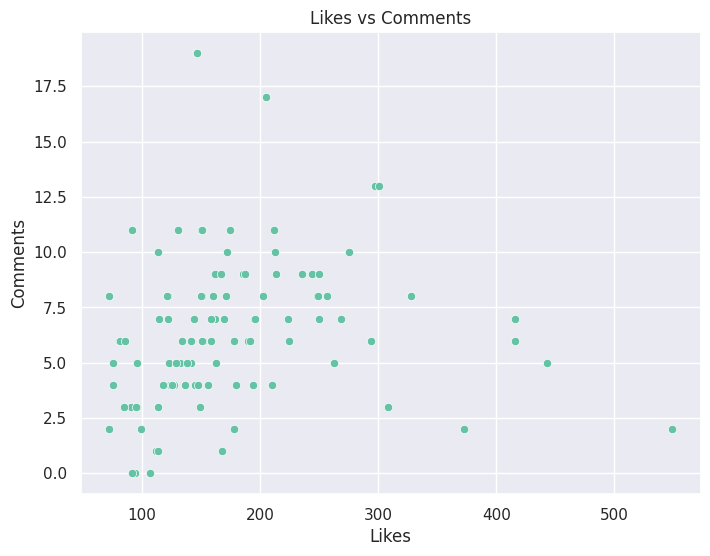

In [35]:
# Filter usage
if 'Filter' in df.columns:
    plt.figure(figsize=(10,5))
    df['Filter'].value_counts().head(10).plot(kind='bar', color='skyblue')
    plt.title("Top Filters Used")
    plt.xlabel("Filter")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

# Likes vs Comments
plt.figure(figsize=(8,6))
sns.scatterplot(x='Likes', y='Comments', data=df)
plt.title("Likes vs Comments")
plt.xlabel("Likes")
plt.ylabel("Comments")
plt.show()

# Monthly Engagement (if date exists)
if 'Date' in df.columns:
    df['Month'] = df['Date'].dt.to_period('M')
    monthly_engagement = df.groupby('Month')[['Likes', 'Comments']].sum()
    monthly_engagement.plot(kind='line', marker='o', figsize=(12,6))
    plt.title("Monthly Engagement")
    plt.xlabel("Month")
    plt.ylabel("Total Engagement")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()


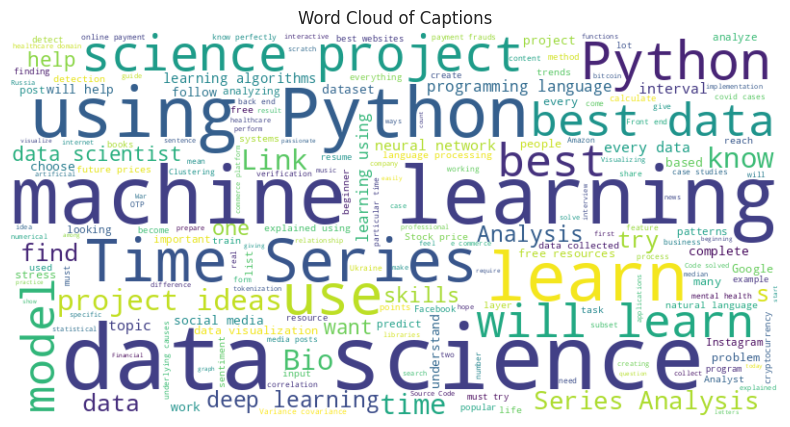

In [36]:
# Word Cloud
if 'Caption' in df.columns:
    text = " ".join(str(caption) for caption in df['Caption'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title("Word Cloud of Captions")
    plt.show()


In [37]:
from IPython.display import Markdown

Markdown("""
### 📌 Conclusion:
- Instagram post engagement varies over time.
- Certain filters and captions attract more likes.
- There is a clear correlation between likes and comments.
- Captions show trends in engagement based on keywords.

### 🚀 Future Ideas:
- Add follower growth analysis
- Predict post engagement using ML
- Explore best posting times
""")



### 📌 Conclusion:
- Instagram post engagement varies over time.
- Certain filters and captions attract more likes.
- There is a clear correlation between likes and comments.
- Captions show trends in engagement based on keywords.

### 🚀 Future Ideas:
- Add follower growth analysis
- Predict post engagement using ML
- Explore best posting times
